# Story 4 — Tồn kho & Returns: Bao nhiêu tiền đang bị để lại trên bàn?

> **Business question:** Doanh nghiệp đang mất doanh thu ở đâu mà không biết — hết hàng khi demand cao, hay hoàn tiền vì sản phẩm không đúng kỳ vọng?

| Chart | Nội dung |
|---|---|
| **4a** | Stockout × Demand Peak — Tổng quan 3 năm (2020–2022) |
| **4a.x** | Stockout × Demand Peak — Drill-down theo Category (2×2 facet) |
| **4b** | Return Rate × Product Margin — Ma trận 2×2 facet theo Category |
| **4c** | Return Reason Breakdown — Heatmap lỗi hệ thống vs. lỗi khách hàng |

## 0. Setup & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = str(Path.cwd().parent)
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import config

# ── Palette nhất quán toàn Story 4 ──────────────────────────────────────────
CATEGORY_COLORS = {
    'Casual'     : '#4E79A7',
    'Outdoor'    : '#59A14F',
    'Streetwear' : '#F28E2B',
    'GenZ'       : '#E15759',
}
ACCENT  = '#E15759'
NEUTRAL = '#BAB0AC'
DARK    = '#2D2D2D'
BG      = '#FAFAFA'

CATEGORIES = ['Casual', 'Outdoor', 'Streetwear', 'GenZ']

sns.set_theme(
    style='ticks',
    rc={
        'figure.facecolor' : BG,
        'axes.facecolor'   : BG,
        'axes.spines.top'  : False,
        'axes.spines.right': False,
        'font.family'      : 'DejaVu Sans',
        'axes.titlesize'   : 12,
        'axes.labelsize'   : 10,
        'xtick.labelsize'  : 9,
        'ytick.labelsize'  : 9,
    }
)

PROCESSED = config.PROCESSED
print('Setup xong ')

Setup xong 


## 1. Load & Prep Data

In [3]:
inventory   = pd.read_parquet(PROCESSED / 'inventory.parquet')
sales       = pd.read_parquet(PROCESSED / 'sales.parquet')
returns     = pd.read_parquet(PROCESSED / 'returns.parquet')
order_items = pd.read_parquet(PROCESSED / 'order_items.parquet')
products    = pd.read_parquet(PROCESSED / 'products.parquet')
orders      = pd.read_parquet(PROCESSED / 'orders.parquet')

sales['Date']              = pd.to_datetime(sales['Date'])
returns['return_date']     = pd.to_datetime(returns['return_date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
orders['order_date']       = pd.to_datetime(orders['order_date'])

print('Shapes:')
for name, df in [('inventory', inventory), ('sales', sales),
                 ('returns', returns), ('order_items', order_items),
                 ('products', products), ('orders', orders)]:
    print(f'  {name:12s}: {df.shape}')

Shapes:
  inventory   : (60247, 16)
  sales       : (3833, 3)
  returns     : (39939, 7)
  order_items : (714669, 7)
  products    : (2412, 8)
  orders      : (646945, 8)


---
## Chart 4a — Stockout × Demand Peak: Tổng quan 3 năm (2020–2022)

Chart chính: toàn bộ categories gộp lại, grouped bar + line Revenue Index theo 3 năm.

In [4]:
# ── Monthly Revenue ──────────────────────────────────────────────────────────
sales['YearMonth'] = sales['Date'].dt.to_period('M')
sales['year']      = sales['Date'].dt.year
sales['month_num'] = sales['Date'].dt.month

monthly_sales = (
    sales.groupby('YearMonth')
    .agg(monthly_revenue=('Revenue', 'sum'),
         n_days=('Revenue', 'count'))
    .reset_index()
)
monthly_sales['avg_daily_revenue'] = monthly_sales['monthly_revenue'] / monthly_sales['n_days']
mean_rev = monthly_sales['monthly_revenue'].mean()
monthly_sales['revenue_index'] = monthly_sales['monthly_revenue'] / mean_rev
monthly_sales['month_dt']  = monthly_sales['YearMonth'].dt.to_timestamp()
monthly_sales['year']      = monthly_sales['month_dt'].dt.year
monthly_sales['month_num'] = monthly_sales['month_dt'].dt.month

# ── Monthly Stockout per Category ────────────────────────────────────────────
inventory['YearMonth'] = inventory['snapshot_date'].dt.to_period('M')

monthly_stockout = (
    inventory.groupby(['YearMonth', 'category'])
    .agg(avg_stockout_days=('stockout_days', 'mean'),
         n_products=('product_id', 'nunique'))
    .reset_index()
)

# ── Merge & est_lost_revenue ─────────────────────────────────────────────────
df4a = monthly_stockout.merge(
    monthly_sales[['YearMonth', 'avg_daily_revenue', 'revenue_index', 'year', 'month_num']],
    on='YearMonth', how='left'
)
# avg_daily_revenue / 4: phân bổ đều cho 4 categories (lower-bound estimate)
df4a['est_lost_revenue'] = df4a['avg_stockout_days'] * (df4a['avg_daily_revenue'] / 4)
df4a['month_dt'] = df4a['YearMonth'].dt.to_timestamp()

# ── Filter 3 năm ─────────────────────────────────────────────────────────────
ANALYSIS_YEARS = [2020, 2021, 2022]
df4a_3y = df4a[df4a['year'].isin(ANALYSIS_YEARS)].copy()

# Aggregate tổng 4 categories per month-year
df4a_monthly = (
    df4a_3y.groupby(['year', 'month_num', 'month_dt'])
    .agg(total_est_lost=('est_lost_revenue', 'sum'),
         avg_revenue_index=('revenue_index', 'mean'))
    .reset_index()
    .sort_values('month_dt')
)

# ── Metrics tổng hợp ─────────────────────────────────────────────────────────
q4_index    = df4a[df4a['month_num'].isin([10, 11, 12])]['revenue_index'].mean()
lost_q4_all = df4a[df4a['month_num'].isin([10, 11, 12])]['est_lost_revenue'].sum()

# Buffer stock
inventory['days_in_month']        = inventory['snapshot_date'].dt.days_in_month
inventory['avg_daily_units_sold']  = inventory['units_sold'] / inventory['days_in_month']
LEAD_TIME_DAYS    = 14
SAFETY_STOCK_DAYS = 7

buffer_by_cat = (
    inventory.groupby('category')
    .agg(avg_daily_units=('avg_daily_units_sold', 'mean'))
    .reset_index()
)
buffer_by_cat['optimal_buffer_units'] = buffer_by_cat['avg_daily_units'] * (LEAD_TIME_DAYS + SAFETY_STOCK_DAYS)
buffer_by_cat['optimal_buffer_Q4']    = buffer_by_cat['optimal_buffer_units'] * q4_index

print(f'Est. Lost Revenue Q4 (10 năm): {lost_q4_all:,.0f} VND')
print(f'Q4 Revenue Index trung bình  : {q4_index:.2f}x')

Est. Lost Revenue Q4 (10 năm): 106,626,649 VND
Q4 Revenue Index trung bình  : 0.66x


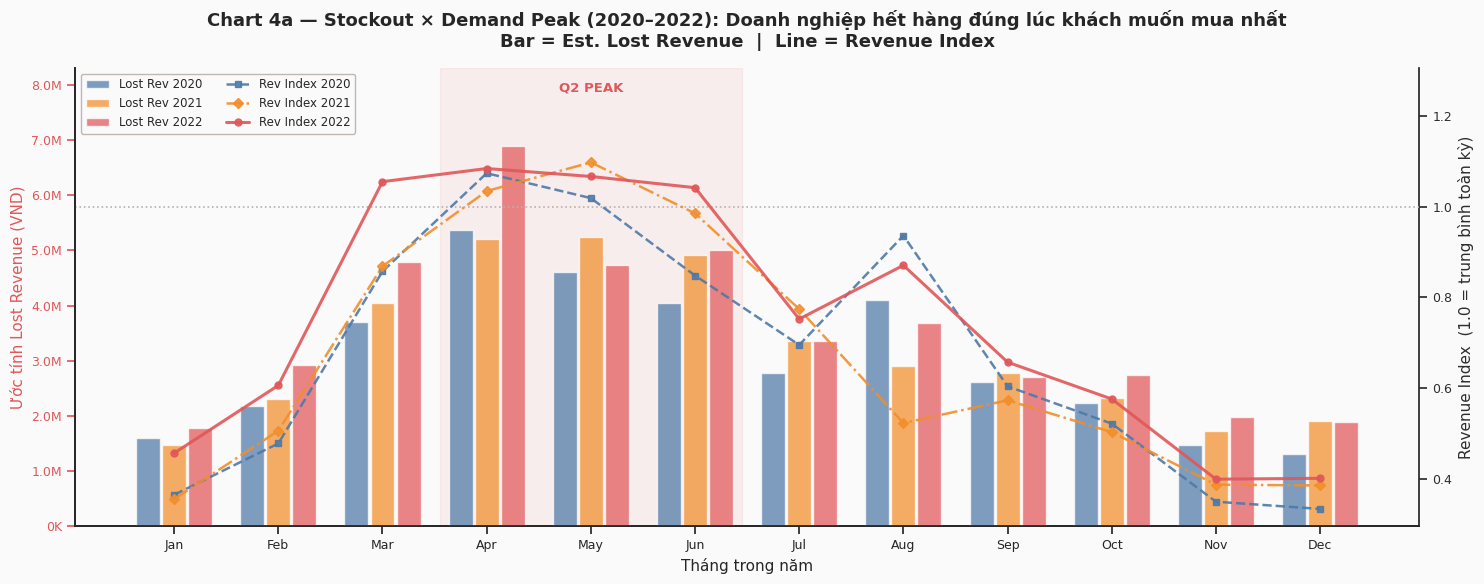

Chart 4a saved 


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 4a — Tổng quan: Grouped bar + Revenue Index line (3 năm)
# ══════════════════════════════════════════════════════════════════════════════

YEAR_STYLES = {
    2020: {'color': '#4E79A7', 'ls': '--',  'marker': 's', 'lw': 1.8},
    2021: {'color': '#F28E2B', 'ls': '-.',  'marker': 'D', 'lw': 1.8},
    2022: {'color': '#E15759', 'ls': '-',   'marker': 'o', 'lw': 2.2},
}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
months    = list(range(1, 13))
bar_width = 0.25
offsets   = {2020: -bar_width, 2021: 0, 2022: bar_width}

fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()

for year in ANALYSIS_YEARS:
    style     = YEAR_STYLES[year]
    year_data = df4a_monthly[df4a_monthly['year'] == year].set_index('month_num')
    vals      = [year_data.loc[m, 'total_est_lost'] if m in year_data.index else 0 for m in months]
    x_pos     = [m + offsets[year] for m in months]
    ax1.bar(x_pos, vals, width=bar_width * 0.92,
            color=style['color'], alpha=0.72, label=f'Lost Rev {year}', zorder=3)

for year in ANALYSIS_YEARS:
    style     = YEAR_STYLES[year]
    year_data = df4a_monthly[df4a_monthly['year'] == year].set_index('month_num')
    rev_vals  = [year_data.loc[m, 'avg_revenue_index'] if m in year_data.index else None for m in months]
    ax2.plot(months, rev_vals, color=style['color'], linewidth=style['lw'],
             linestyle=style['ls'], marker=style['marker'],
             markersize=5, label=f'Rev Index {year}', zorder=4, alpha=0.9)

ax2.axhline(1.0, color=NEUTRAL, linewidth=1.2, linestyle=':', zorder=2)

ax1.set_xlabel('Tháng trong năm', fontsize=11)
ax1.set_ylabel('Ước tính Lost Revenue (VND)', fontsize=11, color=ACCENT)
ax2.set_ylabel('Revenue Index  (1.0 = trung bình toàn kỳ)', fontsize=11, color=DARK)
ax1.set_xticks(months)
ax1.set_xticklabels(MONTH_LABELS)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax1.tick_params(axis='y', colors=ACCENT)
ax2.tick_params(axis='y', colors=DARK)
ax1.set_ylim(bottom=0)

# Q2 highlight
ax1.set_ylim(bottom=0, top=ax1.get_ylim()[1] * 1.15)
ax2.set_ylim(top=ax2.get_ylim()[1] * 1.15)
ax1.axvspan(3.55, 6.45, alpha=0.08, color=ACCENT, zorder=1)
ax1.text(5, ax1.get_ylim()[1] * 0.97, 'Q2 PEAK', ha='center',
         fontsize=9.5, color=ACCENT, fontweight='bold', va='top')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles=handles1 + handles2, labels=labels1 + labels2,
           loc='upper left', fontsize=8.5, framealpha=0.9,
           edgecolor=NEUTRAL, ncol=2)
ax1.set_title(
    'Chart 4a — Stockout × Demand Peak (2020–2022): '
    'Doanh nghiệp hết hàng đúng lúc khách muốn mua nhất\n'
    'Bar = Est. Lost Revenue  |  Line = Revenue Index',
    fontsize=13, fontweight='bold', pad=15)

sns.despine(ax=ax1, top=True, right=False)
fig.tight_layout()
plt.savefig(config.FIGURES / 'chart_4a_stockout_demand.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4a saved ')

---
## Chart 4a.x — Drill-down: Stockout × Demand Peak theo từng Category (2×2 facet)

> **Mục tiêu:** Phát hiện xem pattern stockout có khác nhau giữa các category không —
> Outdoor có thể peak mùa hè, GenZ tập trung cuối năm, v.v.
> Chart chính 4a chỉ thấy *tổng thể bị che khuất*, chart này mới thấy *ai đang gây ra vấn đề*.

In [6]:
# ── Prep: monthly data PER CATEGORY cho 3 năm ───────────────────────────────
# df4a_3y đã có sẵn từ prep trên, chỉ cần không aggregate categories lại

# Revenue index theo tháng (dùng chung cho tất cả categories)
rev_index_lookup = (
    df4a_3y[['year', 'month_num', 'revenue_index']]
    .drop_duplicates()
    .set_index(['year', 'month_num'])['revenue_index']
)

print('Sample df4a_3y per category:')
print(df4a_3y.groupby('category')['est_lost_revenue'].sum()
      .sort_values(ascending=False)
      .apply(lambda x: f'{x:,.0f} VND').to_string())

Sample df4a_3y per category:
category
Streetwear    30,516,967 VND
Casual        29,177,481 VND
GenZ          28,941,798 VND
Outdoor       28,010,643 VND


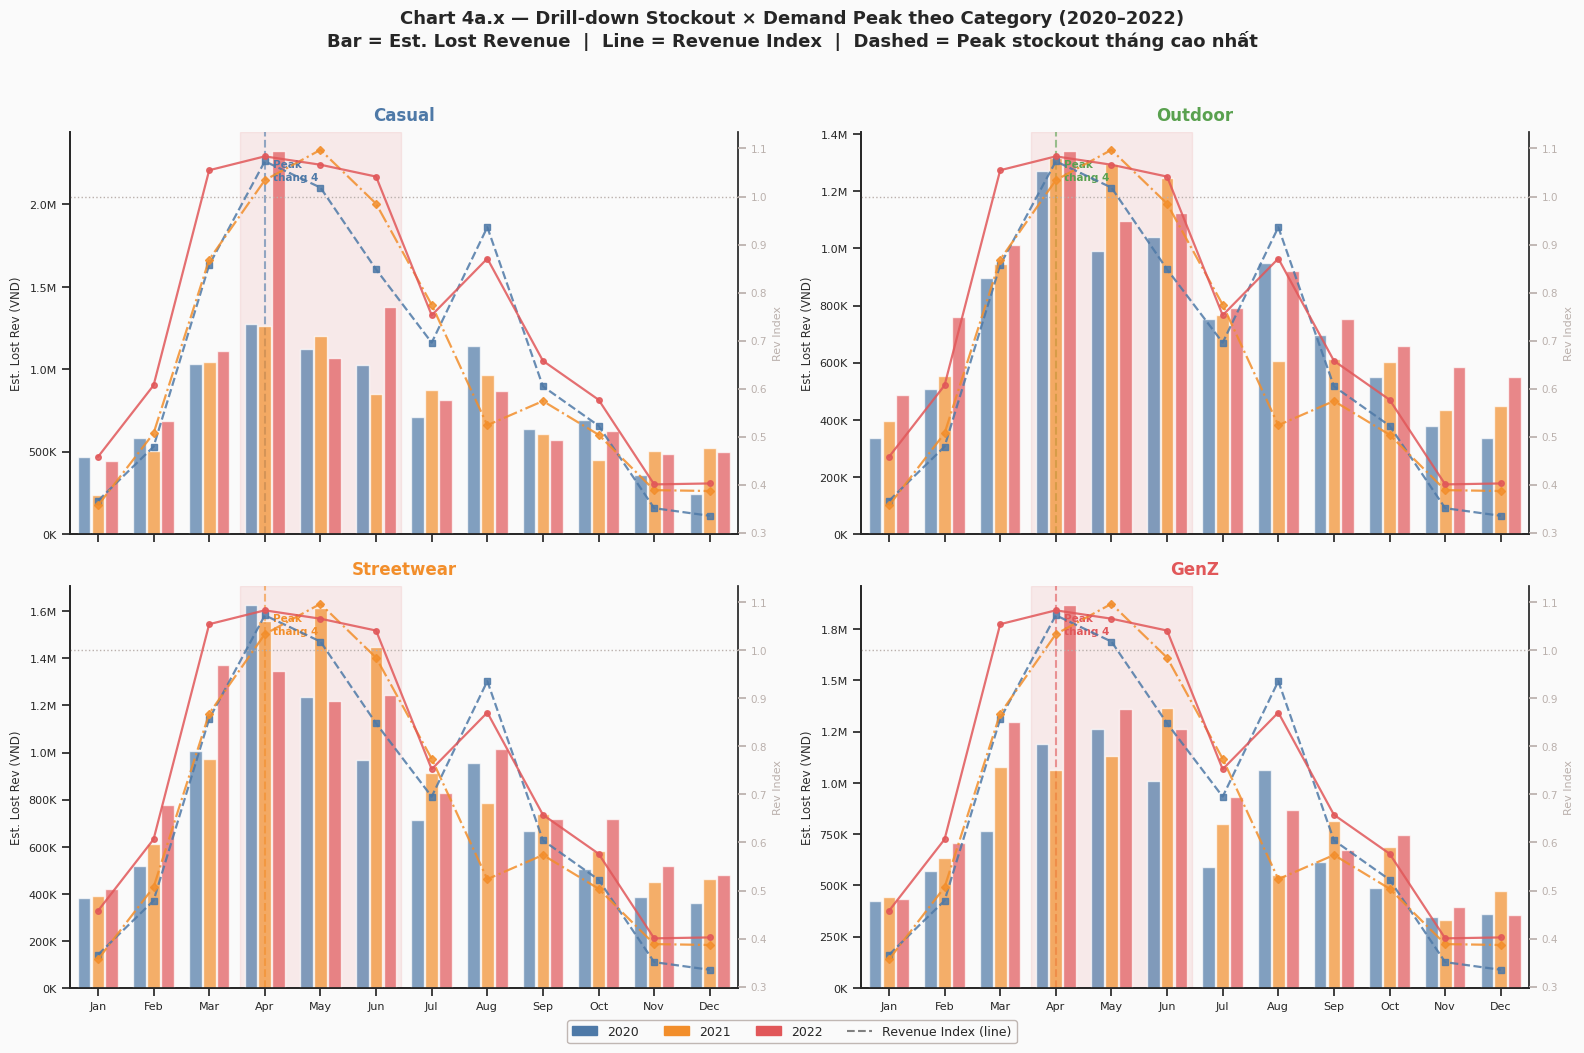

Chart 4a.x saved 


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 4a.x — 2×2 Facet: mỗi subplot = 1 category
# Layout: Casual | Outdoor / Streetwear | GenZ
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes_flat = axes.flatten()

for idx, cat in enumerate(CATEGORIES):
    ax1 = axes_flat[idx]
    ax2 = ax1.twinx()
    cat_color = CATEGORY_COLORS[cat]

    df_cat = df4a_3y[df4a_3y['category'] == cat].copy()

    for year in ANALYSIS_YEARS:
        style    = YEAR_STYLES[year]
        yr_data  = df_cat[df_cat['year'] == year].set_index('month_num')

        # Bar: est_lost_revenue
        bar_vals = [yr_data.loc[m, 'est_lost_revenue'] if m in yr_data.index else 0
                    for m in months]
        x_pos    = [m + offsets[year] for m in months]
        ax1.bar(x_pos, bar_vals, width=bar_width * 0.92,
                color=style['color'], alpha=0.70, label=f'{year}', zorder=3)

        # Line: revenue index (dùng chung, không theo category)
        rev_line = [rev_index_lookup.get((year, m), None) for m in months]
        ax2.plot(months, rev_line,
                 color=style['color'], linewidth=1.6,
                 linestyle=style['ls'], marker=style['marker'],
                 markersize=4, zorder=4, alpha=0.85)

    # Baseline
    ax2.axhline(1.0, color=NEUTRAL, linewidth=1, linestyle=':', zorder=2)

    # Q4 highlight
    ax1.axvspan(3.55, 6.45, alpha=0.10, color=ACCENT, zorder=1)

    # Tìm tháng worst stockout của category này (trung bình 3 năm)
    worst_m = (df_cat.groupby('month_num')['avg_stockout_days']
                     .mean().idxmax())
    worst_v = (df_cat.groupby('month_num')['avg_stockout_days']
                     .mean().max())
    ax1.axvline(worst_m, color=cat_color, linewidth=1.5,
                linestyle='--', alpha=0.6, zorder=2)
    ax1.text(worst_m + 0.15, ax1.get_ylim()[1] * 0.88,
             f'Peak\ntháng {worst_m}', fontsize=7.5,
             color=cat_color, fontweight='bold')

    # Styling per subplot
    ax1.set_title(cat, fontsize=12, fontweight='bold',
                  color=cat_color, pad=8)
    ax1.set_ylabel('Est. Lost Rev (VND)', fontsize=8.5, color=DARK)
    ax2.set_ylabel('Rev Index', fontsize=8, color=NEUTRAL)
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
    ax1.tick_params(axis='y', labelsize=8)
    ax2.tick_params(axis='y', labelsize=7.5, colors=NEUTRAL)
    ax1.set_xlim(0.5, 12.5)

    # X labels chỉ ở hàng dưới
    if idx >= 2:
        ax1.set_xticks(months)
        ax1.set_xticklabels(MONTH_LABELS, fontsize=8)
    else:
        ax1.set_xticks(months)
        ax1.set_xticklabels([])

    sns.despine(ax=ax1, top=True, right=False)

# ── Shared legend ở fig level ─────────────────────────────────────────────────
year_handles = [
    mpatches.Patch(color=YEAR_STYLES[y]['color'], label=str(y))
    for y in ANALYSIS_YEARS
]
rev_handles = [
    Line2D([0], [0], color='grey', linewidth=1.5, linestyle='--',
           label='Revenue Index (line)')
]
fig.legend(handles=year_handles + rev_handles,
           loc='lower center', ncol=4, fontsize=9,
           framealpha=0.9, edgecolor=NEUTRAL,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Chart 4a.x — Drill-down Stockout × Demand Peak theo Category (2020–2022)\n'
    'Bar = Est. Lost Revenue  |  Line = Revenue Index  |  Dashed = Peak stockout tháng cao nhất',
    fontsize=13, fontweight='bold', y=1.02
)
fig.tight_layout()
plt.savefig(config.FIGURES / 'chart_4ax_stockout_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4a.x saved ')

In [8]:
# ── Key Findings 4a + 4a.x ───────────────────────────────────────────────────
print('=' * 65)
print('KEY FINDINGS — Chart 4a & 4a.x')
print('=' * 65)

print('\n[Descriptive] Tháng stockout cao nhất per category (avg 3 năm):')
for cat in CATEGORIES:
    df_cat   = df4a_3y[df4a_3y['category'] == cat]
    worst_m  = df_cat.groupby('month_num')['avg_stockout_days'].mean().idxmax()
    worst_v  = df_cat.groupby('month_num')['avg_stockout_days'].mean().max()
    in_q4    = '← Q4!' if worst_m in [10, 11, 12] else f'← tháng {worst_m}'
    print(f'  {cat:12s}: tháng {worst_m:2d}  ({worst_v:.1f} ngày avg)  {in_q4}')

print(f'\n[Diagnostic] Est. Lost Revenue Q4 tích lũy 10 năm: {lost_q4_all:,.0f} VND')
cat_lost = df4a_3y.groupby('category')['est_lost_revenue'].sum().sort_values(ascending=False)
print('[Diagnostic] Lost Revenue by category (3 năm 2020-2022):')
for cat, val in cat_lost.items():
    print(f'  {cat:12s}: {val:,.0f} VND')

print(f'\n[Predictive] Q4 Revenue Index: {q4_index:.2f}x → cần tăng buffer ~{(q4_index-1)*100:.0f}%')

print(f'\n[Prescriptive] Optimal Buffer Stock per Category:')
for _, row in buffer_by_cat.iterrows():
    print(f'  {row["category"]:12s}: Q4 = {row["optimal_buffer_Q4"]:,.0f} units '
          f'(bình thường: {row["optimal_buffer_units"]:,.0f})')

KEY FINDINGS — Chart 4a & 4a.x

[Descriptive] Tháng stockout cao nhất per category (avg 3 năm):
  Casual      : tháng  4  (1.4 ngày avg)  ← tháng 4
  Outdoor     : tháng  4  (1.1 ngày avg)  ← tháng 4
  Streetwear  : tháng  4  (1.3 ngày avg)  ← tháng 4
  GenZ        : tháng  4  (1.2 ngày avg)  ← tháng 4

[Diagnostic] Est. Lost Revenue Q4 tích lũy 10 năm: 106,626,649 VND
[Diagnostic] Lost Revenue by category (3 năm 2020-2022):
  Streetwear  : 30,516,967 VND
  Casual      : 29,177,481 VND
  GenZ        : 28,941,798 VND
  Outdoor     : 28,010,643 VND

[Predictive] Q4 Revenue Index: 0.66x → cần tăng buffer ~-34%

[Prescriptive] Optimal Buffer Stock per Category:
  Casual      : Q4 = 4 units (bình thường: 6)
  GenZ        : Q4 = 5 units (bình thường: 7)
  Outdoor     : Q4 = 7 units (bình thường: 11)
  Streetwear  : Q4 = 8 units (bình thường: 11)


---
## Chart 4b — Return Rate × Product Margin: Ma trận 2×2 Facet theo Category

Thay vì 1 scatter plot với 1500+ điểm đè lên nhau, phân tách thành 4 subplot —
mỗi category có **ngưỡng median riêng** để xác định quadrant, phản ánh đúng thực tế
từng phân khúc thị trường.

In [9]:
# ── Prep: Product-level metrics ──────────────────────────────────────────────
delivered_orders = orders[orders['order_status'].isin(['delivered','shipped','paid'])]['order_id']
items_del = order_items[order_items['order_id'].isin(delivered_orders)].copy()
items_del['line_revenue'] = items_del['unit_price'] * items_del['quantity']

product_sales = (
    items_del.groupby('product_id')
    .agg(units_sold=('quantity', 'sum'),
         gross_revenue=('line_revenue', 'sum'))
    .reset_index()
)
product_returns = (
    returns.groupby('product_id')
    .agg(units_returned=('return_quantity', 'sum'),
         total_refund=('refund_amount', 'sum'))
    .reset_index()
)

df4b = products.merge(product_sales,  on='product_id', how='left')
df4b = df4b.merge(product_returns, on='product_id', how='left')
df4b[['units_sold','gross_revenue','units_returned','total_refund']] = \
    df4b[['units_sold','gross_revenue','units_returned','total_refund']].fillna(0)

df4b['return_rate']      = df4b['units_returned'] / df4b['units_sold'].clip(lower=1)
df4b['margin_rate']      = (df4b['price'] - df4b['cogs']) / df4b['price'].clip(lower=0.01)
df4b['return_cost_rate'] = df4b['total_refund'] / df4b['gross_revenue'].clip(lower=0.01)
df4b['net_margin']       = df4b['margin_rate'] - df4b['return_cost_rate']

# Filter sản phẩm đủ data
df4b_plot = df4b[df4b['units_sold'] >= 10].copy()

print(f'Products in analysis: {len(df4b_plot)}')
print('\nPer category:')
print(df4b_plot.groupby('category')[['return_rate','margin_rate']].median().round(3).to_string())

Products in analysis: 1454

Per category:
            return_rate  margin_rate
category                            
Casual            0.036        0.248
GenZ              0.039        0.174
Outdoor           0.038        0.203
Streetwear        0.038        0.202


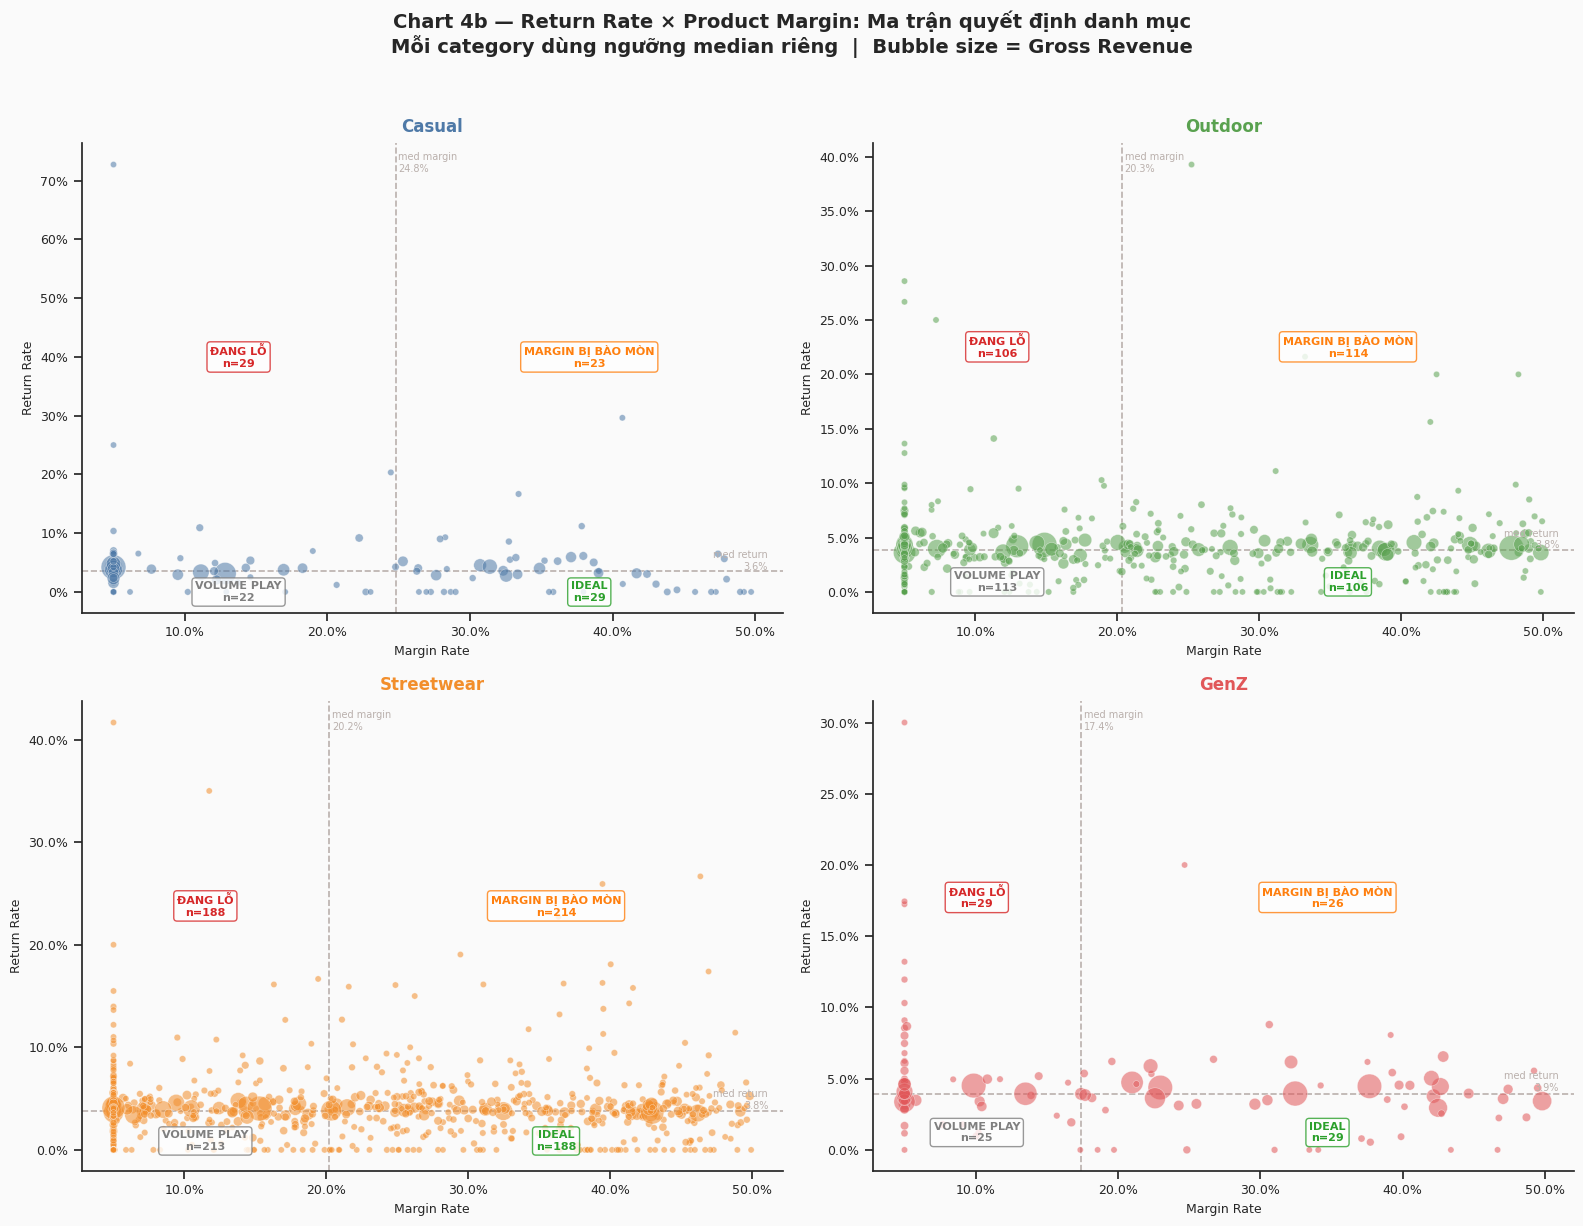

Chart 4b saved 


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 4b — 2×2 Facet scatter, mỗi category tính median riêng
# ══════════════════════════════════════════════════════════════════════════════

QUAD_META = {
    'HM_LR': {'label': 'IDEAL',             'color': '#2ca02c', 'action': 'Tăng tồn kho & marketing'},
    'HM_HR': {'label': 'MARGIN BỊ BÀO MÒN', 'color': '#ff7f0e', 'action': 'Fix return reason'},
    'LM_HR': {'label': 'ĐANG LỖ',           'color': '#d62728', 'action': 'Loại hoặc tăng giá'},
    'LM_LR': {'label': 'VOLUME PLAY',       'color': '#7f7f7f', 'action': 'Giữ nếu cross-sell'},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

# Lưu lại quadrant assignment toàn bộ để dùng cho chart 4c
df4b_plot = df4b_plot.copy()
df4b_plot['quadrant'] = ''

for idx, cat in enumerate(CATEGORIES):
    ax       = axes_flat[idx]
    cat_color = CATEGORY_COLORS[cat]
    df_cat   = df4b_plot[df4b_plot['category'] == cat].copy()

    # Median riêng cho từng category
    m_median = df_cat['margin_rate'].median()
    r_median = df_cat['return_rate'].median()

    # Gán quadrant cho category này
    def get_quad_key(row, mm=m_median, rm=r_median):
        hi_m = row['margin_rate'] >= mm
        hi_r = row['return_rate'] >= rm
        if   hi_m and not hi_r: return 'HM_LR'
        elif hi_m and hi_r:     return 'HM_HR'
        elif not hi_m and hi_r: return 'LM_HR'
        else:                   return 'LM_LR'

    df_cat['quad_key'] = df_cat.apply(get_quad_key, axis=1)

    # Cập nhật quadrant vào df4b_plot (để dùng cho 4c)
    quad_label_map = {
        'HM_LR': 'High Margin\nLow Return',
        'HM_HR': 'High Margin\nHigh Return',
        'LM_HR': 'Low Margin\nHigh Return',
        'LM_LR': 'Low Margin\nLow Return',
    }
    df4b_plot.loc[df_cat.index, 'quadrant'] = df_cat['quad_key'].map(quad_label_map)

    # Normalize bubble size per category
    rev_vals    = df_cat['gross_revenue'].clip(lower=1)
    size_scaled = (rev_vals - rev_vals.min()) / (rev_vals.max() - rev_vals.min()) * 300 + 20

    ax.scatter(
        df_cat['margin_rate'], df_cat['return_rate'],
        s=size_scaled, color=cat_color,
        alpha=0.55, edgecolors='white', linewidth=0.4, zorder=3
    )

    # Quadrant dividers
    ax.axvline(m_median, color=NEUTRAL, linewidth=1.2, linestyle='--', zorder=2)
    ax.axhline(r_median, color=NEUTRAL, linewidth=1.2, linestyle='--', zorder=2)

    # Lấy axis limits sau scatter
    ax.autoscale_view()
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    # Quadrant labels (nhỏ gọn)
    quad_positions = [
        ('HM_LR', m_median + (x_max - m_median)*0.5, r_median - (r_median - y_min)*0.5),
        ('HM_HR', m_median + (x_max - m_median)*0.5, r_median + (y_max - r_median)*0.5),
        ('LM_HR', m_median - (m_median - x_min)*0.5, r_median + (y_max - r_median)*0.5),
        ('LM_LR', m_median - (m_median - x_min)*0.5, r_median - (r_median - y_min)*0.5),
    ]
    for qkey, xq, yq in quad_positions:
        meta = QUAD_META[qkey]
        n_prod = (df_cat['quad_key'] == qkey).sum()
        ax.text(xq, yq,
                f'{meta["label"]}\nn={n_prod}',
                ha='center', va='center', fontsize=8,
                color=meta['color'], fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.80, edgecolor=meta['color'], linewidth=1))

    # Median annotation
    ax.text(m_median + 0.002, y_max * 0.98,
            f'med margin\n{m_median:.1%}',
            fontsize=7, color=NEUTRAL, va='top')
    ax.text(x_max * 0.98, r_median + 0.002,
            f'med return\n{r_median:.1%}',
            fontsize=7, color=NEUTRAL, ha='right')

    ax.set_title(cat, fontsize=12, fontweight='bold', color=cat_color, pad=8)
    ax.set_xlabel('Margin Rate', fontsize=9)
    ax.set_ylabel('Return Rate', fontsize=9)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    sns.despine(ax=ax)

fig.suptitle(
    'Chart 4b — Return Rate × Product Margin: Ma trận quyết định danh mục\n'
    'Mỗi category dùng ngưỡng median riêng  |  Bubble size = Gross Revenue',
    fontsize=14, fontweight='bold', y=1.02
)
fig.tight_layout()
plt.savefig(config.FIGURES / 'chart_4b_return_margin_facet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4b saved ')

In [11]:
# ── Key Findings 4b ──────────────────────────────────────────────────────────
print('=' * 65)
print('KEY FINDINGS — Chart 4b')
print('=' * 65)

for cat in CATEGORIES:
    df_cat = df4b_plot[df4b_plot['category'] == cat]
    print(f'\n[{cat}]')
    quad_sum = (
        df_cat.groupby('quadrant')
        .agg(n=('product_id','count'),
             total_rev=('gross_revenue','sum'),
             total_refund=('total_refund','sum'))
        .reset_index()
    )
    quad_sum['refund_pct'] = quad_sum['total_refund'] / quad_sum['total_rev'] * 100
    quad_sum['quadrant_c'] = quad_sum['quadrant'].str.replace('\n',' ')
    for _, r in quad_sum.iterrows():
        print(f'  {r.quadrant_c:30s}: {r.n:3.0f} SKUs | '
              f'refund bào mòn {r.refund_pct:.1f}% doanh thu')

KEY FINDINGS — Chart 4b

[Casual]
  High Margin High Return       :  23 SKUs | refund bào mòn 4.7% doanh thu
  High Margin Low Return        :  29 SKUs | refund bào mòn 2.3% doanh thu
  Low Margin High Return        :  29 SKUs | refund bào mòn 4.2% doanh thu
  Low Margin Low Return         :  22 SKUs | refund bào mòn 2.6% doanh thu

[Outdoor]
  High Margin High Return       : 114 SKUs | refund bào mòn 4.1% doanh thu
  High Margin Low Return        : 106 SKUs | refund bào mòn 3.0% doanh thu
  Low Margin High Return        : 106 SKUs | refund bào mòn 4.1% doanh thu
  Low Margin Low Return         : 113 SKUs | refund bào mòn 2.8% doanh thu

[Streetwear]
  High Margin High Return       : 214 SKUs | refund bào mòn 4.2% doanh thu
  High Margin Low Return        : 188 SKUs | refund bào mòn 3.1% doanh thu
  Low Margin High Return        : 188 SKUs | refund bào mòn 4.0% doanh thu
  Low Margin Low Return         : 213 SKUs | refund bào mòn 2.9% doanh thu

[GenZ]
  High Margin High Return       :

---
## Chart 4c — Return Reason Breakdown: Heatmap lỗi hệ thống vs. lỗi khách hàng

**Phân loại blame:**
- 🔴 **Lỗi hệ thống / vận hành**: `wrong_size`, `defective`, `late_delivery`
- 🔵 **Lỗi phía khách hàng**: `changed_mind`, `not_as_described`

In [12]:
# ── Prep ──────────────────────────────────────────────────────────────────────
SYSTEM_FAULT   = {'wrong_size', 'defective', 'late_delivery'}
CUSTOMER_FAULT = {'changed_mind', 'not_as_described'}

def blame_type(reason):
    if reason in SYSTEM_FAULT:   return 'Lỗi hệ thống / vận hành'
    if reason in CUSTOMER_FAULT: return 'Lỗi phía khách hàng'
    return 'Khác'

returns_aug = returns.merge(products[['product_id','category']], on='product_id', how='left')
returns_aug['blame_type'] = returns_aug['return_reason'].map(blame_type)
returns_aug = returns_aug.merge(
    df4b_plot[['product_id','quadrant']], on='product_id', how='left'
)

# Overall
reason_overall = (
    returns_aug.groupby('return_reason')
    .agg(n_returns=('return_id','count'), total_refund=('refund_amount','sum'))
    .reset_index()
    .sort_values('n_returns', ascending=False)
)
reason_overall['pct']        = reason_overall['n_returns'] / reason_overall['n_returns'].sum() * 100
reason_overall['blame_type'] = reason_overall['return_reason'].map(blame_type)

# By Category
reason_by_cat = (
    returns_aug.groupby(['category','return_reason'])
    .agg(n_returns=('return_id','count'))
    .reset_index()
)
cat_totals = reason_by_cat.groupby('category')['n_returns'].transform('sum')
reason_by_cat['pct'] = reason_by_cat['n_returns'] / cat_totals * 100

# By Quadrant
reason_by_quad = (
    returns_aug[returns_aug['quadrant'].notna()]
    .groupby(['quadrant','return_reason'])
    .agg(n_returns=('return_id','count'))
    .reset_index()
)
quad_totals = reason_by_quad.groupby('quadrant')['n_returns'].transform('sum')
reason_by_quad['pct'] = reason_by_quad['n_returns'] / quad_totals * 100

REASONS_ORDER = ['wrong_size','defective','late_delivery','changed_mind','not_as_described']

cat_pivot = (
    reason_by_cat
    .pivot(index='return_reason', columns='category', values='pct')
    .reindex(REASONS_ORDER)
)
quad_pivot = (
    reason_by_quad
    .pivot(index='return_reason', columns='quadrant', values='pct')
    .reindex(REASONS_ORDER)
)
quad_pivot.columns = [c.replace('\n',' ') for c in quad_pivot.columns]

print('Return reason overall:')
print(reason_overall[['return_reason','pct','blame_type']].to_string(index=False))

Return reason overall:
   return_reason       pct              blame_type
      wrong_size 34.970831 Lỗi hệ thống / vận hành
       defective 20.080623 Lỗi hệ thống / vận hành
not_as_described 17.614362     Lỗi phía khách hàng
    changed_mind 17.353965     Lỗi phía khách hàng
   late_delivery  9.980220 Lỗi hệ thống / vận hành


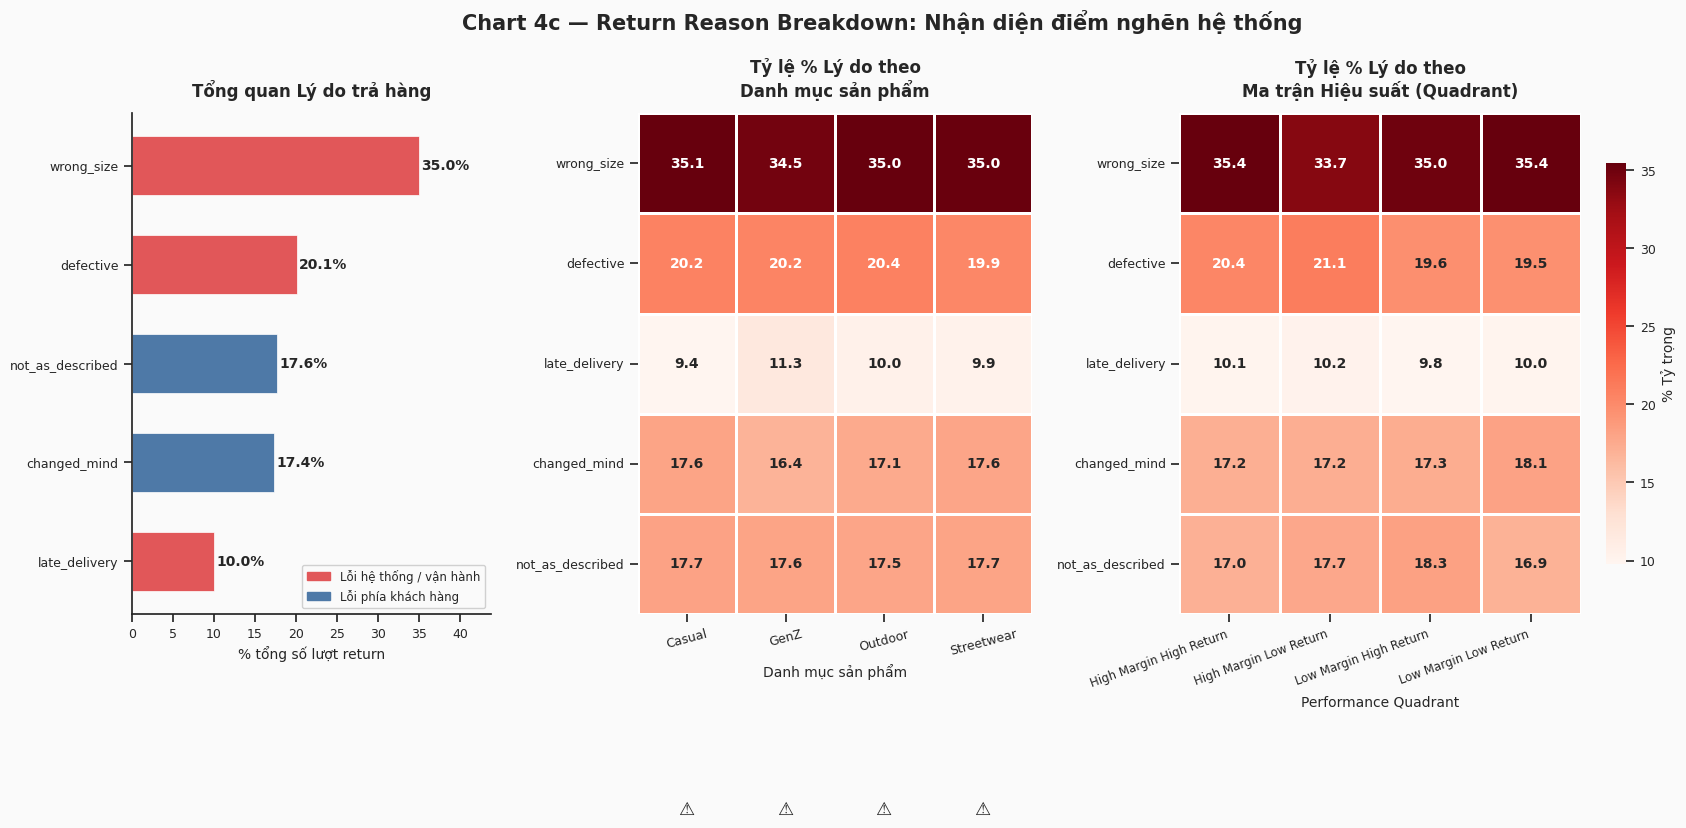

Chart 4c saved 


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 4c — 3-panel: Horizontal bar | Heatmap by Category | Heatmap by Quadrant
# ══════════════════════════════════════════════════════════════════════════════

BLAME_COLORS = {
    'Lỗi hệ thống / vận hành': '#E15759',
    'Lỗi phía khách hàng'     : '#4E79A7',
}

fig = plt.figure(figsize=(20, 6.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35, width_ratios=[1, 1.1, 1.4])
ax_left   = fig.add_subplot(gs[0, 0])
ax_center = fig.add_subplot(gs[0, 1])
ax_right  = fig.add_subplot(gs[0, 2])

# ── Panel 1: Overall horizontal bar ─────────────────────────────────────────
reasons_sorted = reason_overall.sort_values('pct')
bar_colors = [BLAME_COLORS.get(b, NEUTRAL) for b in reasons_sorted['blame_type']]
bars = ax_left.barh(
    reasons_sorted['return_reason'], reasons_sorted['pct'],
    color=bar_colors, edgecolor='white', linewidth=0.5, height=0.6
)
for bar, pct in zip(bars, reasons_sorted['pct']):
    ax_left.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{pct:.1f}%', va='center', ha='left', fontsize=10, fontweight='bold')
ax_left.set_xlabel('% tổng số lượt return', fontsize=10)
ax_left.set_title('Tổng quan Lý do trả hàng', fontsize=12, fontweight='bold', pad=12)
ax_left.set_xlim(0, reasons_sorted['pct'].max() * 1.25)
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in BLAME_COLORS.items()]
ax_left.legend(handles=legend_patches, loc='lower right', fontsize=8.5, framealpha=0.9)
sns.despine(ax=ax_left)

# ── Panel 2: Heatmap by Category ─────────────────────────────────────────────
sns.heatmap(
    cat_pivot, annot=True, fmt='.1f', cmap='Reds',
    cbar=False, linewidths=0.8, linecolor='white',
    ax=ax_center, annot_kws={'size': 10, 'weight': 'bold'}
)
ax_center.set_ylabel('')
ax_center.set_xlabel('Danh mục sản phẩm', fontsize=10)
ax_center.set_title('Tỷ lệ % Lý do theo\nDanh mục sản phẩm', fontsize=12, fontweight='bold', pad=12)
ax_center.tick_params(axis='y', rotation=0, labelsize=9)
ax_center.tick_params(axis='x', rotation=15, labelsize=9)

for i, cat in enumerate(cat_pivot.columns):
    ws_val = cat_pivot.loc['wrong_size', cat] if 'wrong_size' in cat_pivot.index else 0
    if ws_val > 30:
        ax_center.text(i + 0.5, -0.4, '⚠️', ha='center', fontsize=13,
                       transform=ax_center.get_xaxis_transform())

# ── Panel 3: Heatmap by Quadrant ─────────────────────────────────────────────
sns.heatmap(
    quad_pivot, annot=True, fmt='.1f', cmap='Reds',
    cbar=True, cbar_kws={'label': '% Tỷ trọng', 'shrink': 0.8},
    linewidths=0.8, linecolor='white',
    ax=ax_right, annot_kws={'size': 10, 'weight': 'bold'}
)
ax_right.set_ylabel('')
ax_right.set_xlabel('Performance Quadrant', fontsize=10)
ax_right.set_title('Tỷ lệ % Lý do theo\nMa trận Hiệu suất (Quadrant)', fontsize=12, fontweight='bold', pad=12)
ax_right.tick_params(axis='y', rotation=0, labelsize=9)
ax_right.tick_params(axis='x', rotation=20, labelsize=8.5)
plt.setp(ax_right.get_xticklabels(), ha='right')

fig.suptitle(
    'Chart 4c — Return Reason Breakdown: Nhận diện điểm nghẽn hệ thống',
    fontsize=15, fontweight='bold', y=1.04
)
fig.tight_layout()
plt.savefig(config.FIGURES / 'chart_4c_return_reason_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4c saved ')

In [15]:
# ── Key Findings 4c ──────────────────────────────────────────────────────────
print('=' * 65)
print('KEY FINDINGS — Chart 4c')
print('=' * 65)

blame_summary = (
    returns_aug.groupby('blame_type')
    .agg(n=('return_id','count'), refund=('refund_amount','sum'))
    .reset_index()
)
blame_summary['pct'] = blame_summary['n'] / blame_summary['n'].sum() * 100

print('\n[Descriptive] Tỷ lệ lỗi hệ thống vs. khách hàng:')
for _, row in blame_summary.iterrows():
    print(f'  {row["blame_type"]:35s}: {row["pct"]:5.1f}%  '
          f'({row["n"]:,} returns | refund: {row["refund"]:,.2f} VND)')

print('\n[Diagnostic] % wrong_size per category:')
ws_by_cat = reason_by_cat[reason_by_cat['return_reason'] == 'wrong_size'][['category','pct']]
for _, r in ws_by_cat.sort_values('pct', ascending=False).iterrows():
    flag = ' ← Fix size guide ngay!' if r['pct'] > 25 else ''
    print(f'  {r["category"]:12s}: {r["pct"]:5.1f}%{flag}')

print('\n[Diagnostic] High Margin + High Return — Top return reasons:')
hh_quad = 'High Margin\nHigh Return'
hh_data = reason_by_quad[reason_by_quad['quadrant'] == hh_quad].sort_values('pct', ascending=False)
if not hh_data.empty:
    for _, r in hh_data.head(3).iterrows():
        print(f'  {r["return_reason"]:20s}: {r["pct"]:5.1f}%')

lh_quad   = 'Low Margin\nHigh Return'
lh_refund = returns_aug[returns_aug['quadrant'] == lh_quad]['refund_amount'].sum()
print(f'\n[Prescriptive] Tổng refund từ Low Margin + High Return: {lh_refund:,.2f} VND')
print('  → Loại hoặc redesign nhóm sản phẩm này để dừng chảy máu margin.')

KEY FINDINGS — Chart 4c

[Descriptive] Tỷ lệ lỗi hệ thống vs. khách hàng:
  Lỗi hệ thống / vận hành            :  65.0%  (25,973 returns | refund: 330,223,556.77 VND)
  Lỗi phía khách hàng                :  35.0%  (13,966 returns | refund: 180,374,949.78 VND)

[Diagnostic] % wrong_size per category:
  Casual      :  35.1% ← Fix size guide ngay!
  Outdoor     :  35.0% ← Fix size guide ngay!
  Streetwear  :  35.0% ← Fix size guide ngay!
  GenZ        :  34.5% ← Fix size guide ngay!

[Diagnostic] High Margin + High Return — Top return reasons:
  wrong_size          :  35.4%
  defective           :  20.4%
  changed_mind        :  17.2%

[Prescriptive] Tổng refund từ Low Margin + High Return: 213,980,408.98 VND
  → Loại hoặc redesign nhóm sản phẩm này để dừng chảy máu margin.


---
## Summary — Story 4: Tiền đang bị để lại trên bàn ở đâu?

| Chart | Góc độ | Vấn đề phát hiện | Hành động đề xuất |
|---|---|---|---|
| **4a** | Stockout tổng quan | Hết hàng tập trung Q4 — pattern lặp lại 3 năm liên tiếp | Nhập buffer stock sớm hơn 6–8 tuần |
| **4a.x** | Stockout theo category | Mỗi category có peak stockout khác nhau | Reorder strategy riêng cho từng category |
| **4b** | Margin × Return facet | Mỗi category có phân bố quadrant khác nhau | Ưu tiên fix theo đặc thù từng phân khúc |
| **4c** | Return reason | Lỗi hệ thống chiếm phần lớn → có thể can thiệp | Fix size guide, cải thiện QC, tối ưu logistics |